In [240]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt 

In [241]:
breast_data = pd.read_csv("Breast_Cancer.csv")
breast_data

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,Alive
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,Alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,Alive
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,72,Alive


***Preprocessing***

Po poprzedniej analizie wiadomo ze dataset nie zawiera zadnych wartosci Null, wiec preprocessing jest dosc uproszczony. Dlatego tez nie potrzeba znow uzywac .info aby zapoznac sie ze specyfika danych.

In [242]:
col_to_change = breast_data.select_dtypes(include=["object"]).columns
col_to_change

Index(['Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Estrogen Status',
       'Progesterone Status', 'Status'],
      dtype='object')

In [243]:
for col in col_to_change:
    print(f"-----{col}-----")
    print(breast_data[col].unique())

-----Race-----
['White' 'Black' 'Other']
-----Marital Status-----
['Married' 'Divorced' 'Single ' 'Widowed' 'Separated']
-----T Stage -----
['T1' 'T2' 'T3' 'T4']
-----N Stage-----
['N1' 'N2' 'N3']
-----6th Stage-----
['IIA' 'IIIA' 'IIIC' 'IIB' 'IIIB']
-----differentiate-----
['Poorly differentiated' 'Moderately differentiated' 'Well differentiated'
 'Undifferentiated']
-----Grade-----
['3' '2' '1' ' anaplastic; Grade IV']
-----A Stage-----
['Regional' 'Distant']
-----Estrogen Status-----
['Positive' 'Negative']
-----Progesterone Status-----
['Positive' 'Negative']
-----Status-----
['Alive' 'Dead']


I teraz wiadomo jakie kolumny nalezy zamienic z tekstowych na liczbowe aby kazdy model mogl podejsc do nauki i klasyfikacji.

In [244]:
#hierarchiczne

hierarchie = {
    "T Stage ": ['T1', 'T2', 'T3', 'T4'],
    "N Stage": ['N1', 'N2', 'N3'],
    "6th Stage": ['IIA', 'IIB', 'IIIA', 'IIIB', 'IIIC'],
    "Grade": ['1', '2', '3', ' anaplastic; Grade IV'],
    "differentiate": ['Undifferentiated', 'Poorly differentiated', 'Moderately differentiated', 'Well differentiated'] 
}

for name, order in hierarchie.items():
    ordinal_enc = OrdinalEncoder(categories=[order])

    breast_data[name] = ordinal_enc.fit_transform(breast_data[[name]])

# niehierarchiczne
col_onehot = ["Race", "Marital Status", "A Stage", "Estrogen Status", "Progesterone Status", "Status"]

for name in col_onehot:
    onehot_enc = OneHotEncoder(sparse_output=False, drop="first")
    coded = onehot_enc.fit_transform(breast_data[[name]])
    new_col_names = onehot_enc.get_feature_names_out([name])

    pd_temp = pd.DataFrame(data=coded, columns=new_col_names, index=breast_data.index)

    breast_data = pd.concat([breast_data, pd_temp], axis=1)
    breast_data = breast_data.drop(columns=name)
    
breast_data

,Age,T Stage,N Stage,6th Stage,differentiate,Grade,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months,Race_Other,Race_White,Marital Status_Married,Marital Status_Separated,Marital Status_Single,Marital Status_Widowed,A Stage_Regional,Estrogen Status_Positive,Progesterone Status_Positive,Status_Dead
0,68,0.0,0.0,0.0,1.0,2.0,4,24,1,60,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,50,1.0,1.0,2.0,2.0,1.0,35,14,5,62,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,58,2.0,2.0,4.0,2.0,1.0,63,14,7,75,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,58,0.0,0.0,0.0,1.0,2.0,18,2,1,84,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,47,1.0,0.0,1.0,1.0,2.0,41,3,1,50,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62,0.0,0.0,0.0,2.0,1.0,9,1,1,49,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4020,56,1.0,1.0,2.0,2.0,1.0,46,14,8,69,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4021,68,1.0,0.0,1.0,2.0,1.0,22,11,3,69,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4022,58,1.0,0.0,1.0,2.0,1.0,44,11,1,72,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0


In [245]:
breast_data.describe()

,Age,T Stage,N Stage,6th Stage,differentiate,Grade,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months,Race_Other,Race_White,Marital Status_Married,Marital Status_Separated,Marital Status_Single,Marital Status_Widowed,A Stage_Regional,Estrogen Status_Positive,Progesterone Status_Positive,Status_Dead
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,0.784791,0.438370,1.321819,1.849404,1.150596,30.473658,14.357107,4.158052,71.297962,0.079523,0.848161,0.656809,0.011183,0.152833,0.058400,0.977137,0.933151,0.826541,0.153082
std,8.963134,0.765531,0.693479,1.266624,0.638234,0.638234,21.119696,8.099675,5.109331,22.921430,0.270587,0.358909,0.474834,0.105169,0.359871,0.234527,0.149485,0.249791,0.378691,0.360111
min,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,0.000000,1.000000,1.000000,16.000000,9.000000,1.000000,56.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
50%,54.000000,1.000000,0.000000,1.000000,2.000000,1.000000,25.000000,14.000000,2.000000,73.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
75%,61.000000,1.000000,1.000000,2.000000,2.000000,2.000000,38.000000,19.000000,5.000000,90.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
max,69.000000,3.000000,2.000000,4.000000,3.000000,3.000000,140.000000,61.000000,46.000000,107.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Wnioski sa jak poprzednio.

***Feature Selection***

<Axes: title={'center': 'Analiza korelacji parametrow raka piersi.'}>

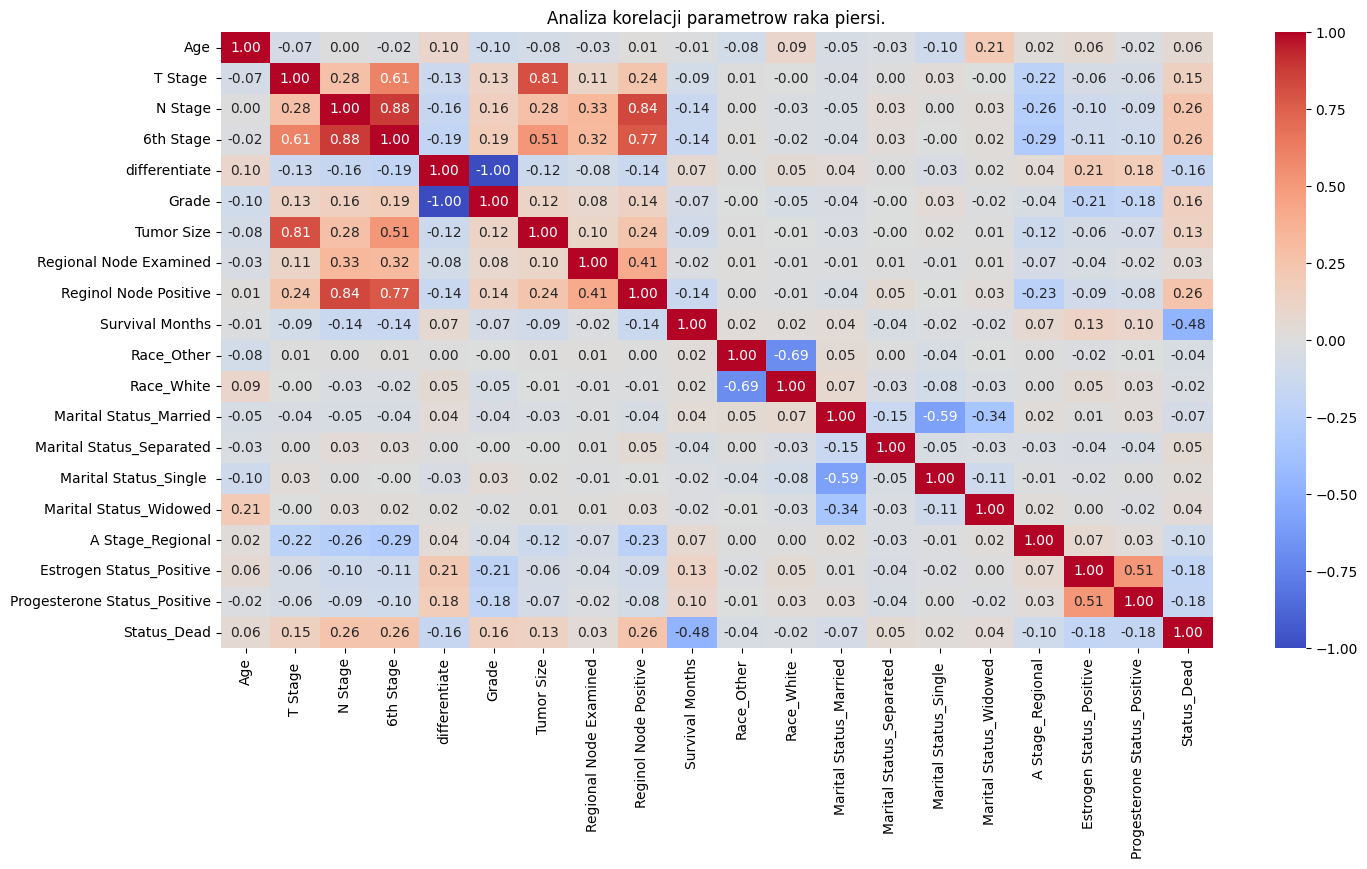

In [246]:
corr = breast_data.corr()
plt.figure(figsize=(16,8))
plt.title("Analiza korelacji parametrow raka piersi.")
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt="0.2f")

In [247]:
y = breast_data["Status_Dead"]
X = breast_data[["T Stage ", "N Stage", "Age"]]

***Data Splitting***

In [248]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

***Model Selection***

Narazie modele bez zadnych customowych parametrow zostana wytrenowane i sprawdzone na malej dawce parametrow zeby sprawdzic jak sobie radza. 

---LogisticRegression---
Wynik precision: 0.6
Wynik recall: 0.025
Wynik roc_auc: 0.5110401459854014


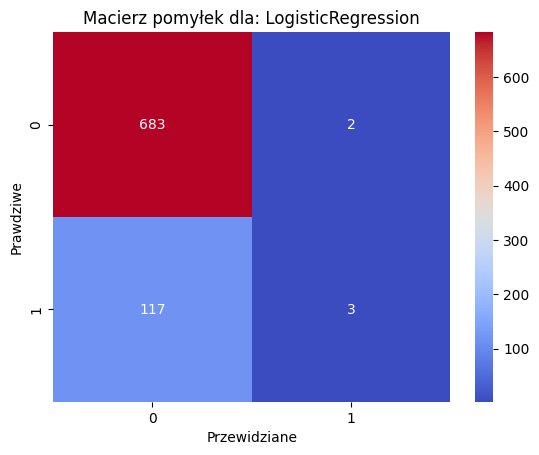

---RandomForestClassifier---
Wynik precision: 0.3541666666666667
Wynik recall: 0.14166666666666666
Wynik roc_auc: 0.5482055961070559


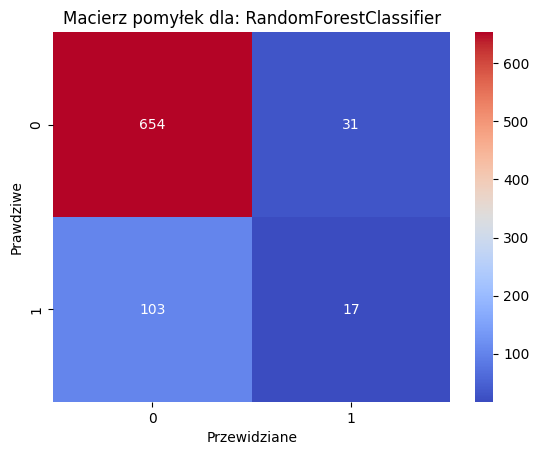

---XGBClassifier---
Wynik precision: 0.40540540540540543
Wynik recall: 0.125
Wynik roc_auc: 0.546441605839416


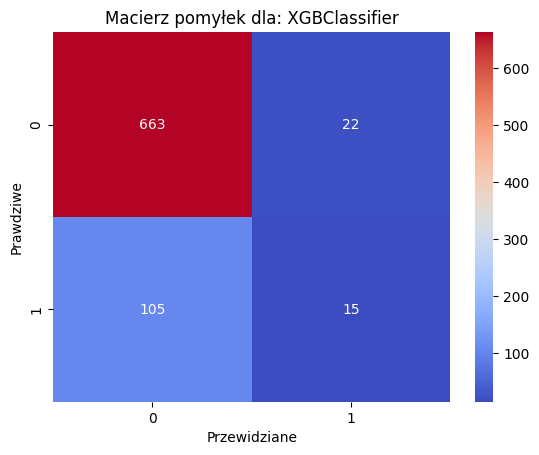

In [249]:
logistic = LogisticRegression(random_state=42)
forest = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(random_state=42)

models = [logistic, forest, xgb]

for model in models:
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    precision = precision_score(y_pred=y_pred, y_true=y_test)
    recall = recall_score(y_pred=y_pred, y_true=y_test)
    roc_auc = roc_auc_score(y_score=y_pred, y_true=y_test)
    conf_mat = confusion_matrix(y_pred=y_pred, y_true=y_test)

    name = model.__class__.__name__

    print(f"---{name}---")
    print(f"Wynik precision: {precision}")
    print(f"Wynik recall: {recall}")
    print(f"Wynik roc_auc: {roc_auc}")
    plt.title(f"Macierz pomyłek dla: {name}")
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap='coolwarm')
    plt.ylabel("Prawdziwe")
    plt.xlabel("Przewidziane")
    plt.show()

Wszystkie trzy modele maja wynik auc_roc na poziomie ponad 0.5, co oznacza ze sa takie sobie. Problem jednak lezy w metryce recall, ktora w kazdym modelu nie przekracza 0.2. Oznacza to ze jest duze ryzyko pominiecia pacjenta chorego i sklasyfikowania go jako zdrowego (False Negative). 

Kolejnym krokiem bedzie dolozenie zmiennych aby zobaczyc czy to rzeczywiscie wplynie na metryke Recall.

***Feature Engineering***

In [250]:
y = breast_data["Status_Dead"]
X = breast_data[["Tumor Size", "N Stage", "Age", "Reginol Node Positive", "Estrogen Status_Positive", "Progesterone Status_Positive", "Grade"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---LogisticRegression---
Wynik precision: 0.6666666666666666
Wynik recall: 0.15
Wynik roc_auc: 0.5684306569343065


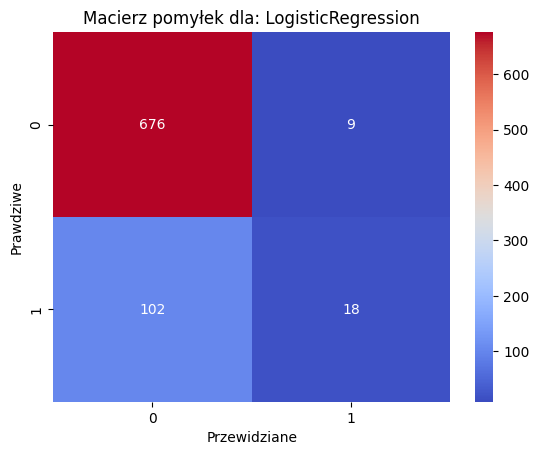

---RandomForestClassifier---
Wynik precision: 0.42857142857142855
Wynik recall: 0.25
Wynik roc_auc: 0.5958029197080291


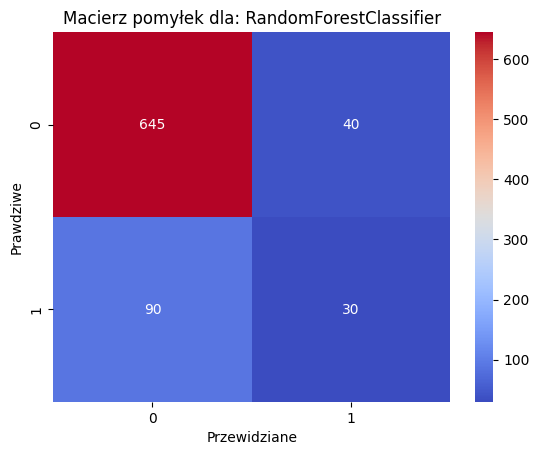

---XGBClassifier---
Wynik precision: 0.48148148148148145
Wynik recall: 0.21666666666666667
Wynik roc_auc: 0.5878953771289538


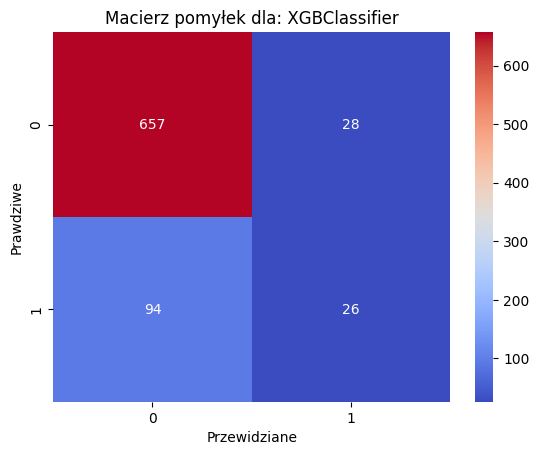

In [251]:
logistic = LogisticRegression(random_state=42)
forest = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(random_state=42)

models = [logistic, forest, xgb]

for model in models:
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    precision = precision_score(y_pred=y_pred, y_true=y_test)
    recall = recall_score(y_pred=y_pred, y_true=y_test)
    roc_auc = roc_auc_score(y_score=y_pred, y_true=y_test)
    conf_mat = confusion_matrix(y_pred=y_pred, y_true=y_test)

    name = model.__class__.__name__

    print(f"---{name}---")
    print(f"Wynik precision: {precision}")
    print(f"Wynik recall: {recall}")
    print(f"Wynik roc_auc: {roc_auc}")
    plt.title(f"Macierz pomyłek dla: {name}")
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap='coolwarm')
    plt.ylabel("Prawdziwe")
    plt.xlabel("Przewidziane")
    plt.show()

Dodatkowe zmienne nie przyniosly efektu, pomimo dolaczenia do nauki modelu danych mowiacych o stanie wezlow chlonnych i receptorow wynik recall dalej pozostaje bardzo niski. Pora na hiperparametryzacje.

In [252]:
# parametryzacja LogisticRegressor

logistic_params = {
    "class_weight": ["balanced"], #dostosowanie wag przy nierownej liczbie klas
    "C": [0.01, 0.1, 1, 10, 100]  #agresywnosc dopasowania sie do danych
}

logistic = LogisticRegression(random_state=42)

logistic_grid = GridSearchCV(
    estimator=logistic,
    param_grid=logistic_params,
    scoring="recall",
    cv=3,
    verbose=1
)

logistic_grid.fit(X_train_scaled, y_train)

print(f"Najlepsze parametry dla {logistic.__class__.__name__}: {logistic_grid.best_params_}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Najlepsze parametry dla LogisticRegression: {'C': 0.1, 'class_weight': 'balanced'}


In [253]:
# parametryzacja RandomForestClassifier

forest_params = {
    "class_weight": ["balanced", "balanced_subsample"],
    "max_depth": [2, 3, 4, 5],
    "n_estimators": [50, 100, 200, 300],
    "min_samples_leaf": [2, 5, 10]
}

forest = RandomForestClassifier(random_state=42)

forest_grid = GridSearchCV(
    estimator=forest,
    param_grid=forest_params,
    scoring="recall",
    cv=3,
    verbose=1
)

forest_grid.fit(X_train_scaled, y_train)

print(f"Najlepsze parametry dla {forest.__class__.__name__}: {forest_grid.best_params_}")

Fitting 3 folds for each of 96 candidates, totalling 288 fits
Najlepsze parametry dla RandomForestClassifier: {'class_weight': 'balanced', 'max_depth': 2, 'min_samples_leaf': 2, 'n_estimators': 200}


In [254]:
# parametryzacja XGBClassifier

xgb_params = {
    "scale_pos_weight": [5, 5.5, 6],  #balans klas, kara za przeoczenie chorego powyzej/pozniej jakiegos zakresu
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [2, 3, 4, 5],
    "gamma": [0, 1] # ograniczenie ciec
}

xgb = XGBClassifier(random_state = 42)

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    scoring="recall",
    cv=3,
    verbose=1
)

xgb_grid.fit(X_train_scaled, y_train)

print(f"Najlepsze parametry dla {xgb.__class__.__name__}: {xgb_grid.best_params_}")

Fitting 3 folds for each of 288 candidates, totalling 864 fits
Najlepsze parametry dla XGBClassifier: {'gamma': 0, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 50, 'scale_pos_weight': 6}


Znajac juz najlepsze kombinacje pora wyternowac modele na zablokowanych parametrach i zobaczyc jak zmieni sie recall.

In [255]:
y = breast_data["Status_Dead"]
X = breast_data[["Tumor Size", "N Stage", "Age", "Reginol Node Positive", "Estrogen Status_Positive", "Progesterone Status_Positive", "Grade"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---LogisticRegression---
Wynik precision: 0.29508196721311475
Wynik recall: 0.6
Wynik roc_auc: 0.6744525547445256


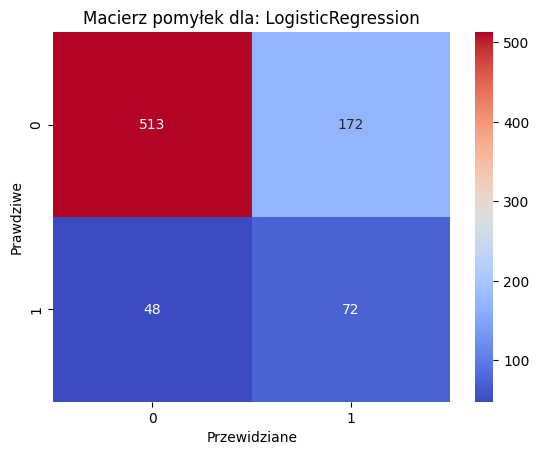

---RandomForestClassifier---
Wynik precision: 0.27697841726618705
Wynik recall: 0.6416666666666667
Wynik roc_auc: 0.67411800486618


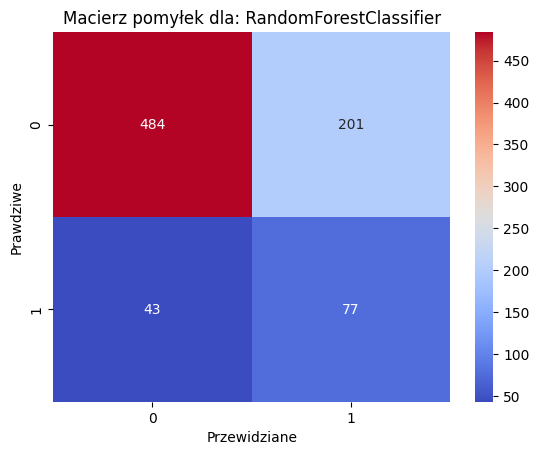

---XGBClassifier---
Wynik precision: 0.24645892351274787
Wynik recall: 0.725
Wynik roc_auc: 0.6683394160583942


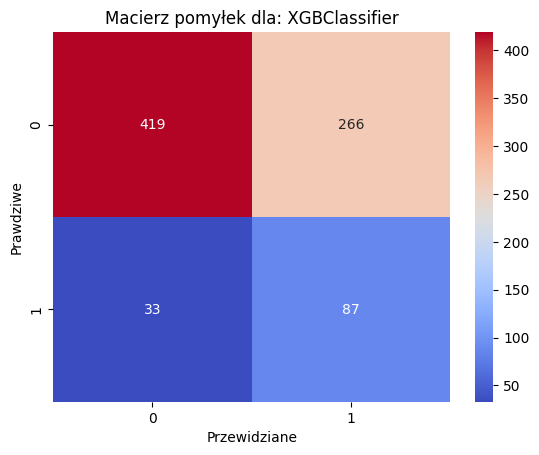

In [256]:
logistic = LogisticRegression(
    class_weight='balanced',
    C=0.1
)

forest = RandomForestClassifier(
    class_weight = 'balanced',
    max_depth=2,
    min_samples_leaf=2,
    n_estimators=200,
    random_state=42
)

xgb = XGBClassifier(
    gamma = 0,
    learning_rate = 0.01,
    max_depth = 4,
    n_estimators = 50,
    scale_pos_weight = 6,
    random_state = 42
)

models = [logistic, forest, xgb]

for model in models:
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    precision = precision_score(y_pred=y_pred, y_true=y_test)
    recall = recall_score(y_pred=y_pred, y_true=y_test)
    roc_auc = roc_auc_score(y_score=y_pred, y_true=y_test)
    conf_mat = confusion_matrix(y_pred=y_pred, y_true=y_test)

    name = model.__class__.__name__

    print(f"---{name}---")
    print(f"Wynik precision: {precision}")
    print(f"Wynik recall: {recall}")
    print(f"Wynik roc_auc: {roc_auc}")
    plt.title(f"Macierz pomyłek dla: {name}")
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap='coolwarm')
    plt.ylabel("Prawdziwe")
    plt.xlabel("Przewidziane")
    plt.show()

Najlepiej wypadl model XGBClassifier czyli ten teoretycznie najbardziej skomplikowany. Jego wynik jednak w dalszym ciagu nie jest do konca zadowalajacy.
Jedynym co w tym wypadku zostaje to reczne manipulowanie progiem predict_proba w celu zwiekszenia wartosci recall ostatecznym kosztem precision (ktory i tak w takich analizach nie jest zbytnio brany pod uwaage, lepiej przeholowac niz niedoszacowac.)

Nowa wartosc metryki recall dla progu 0.45: 0.8833333333333333
Nowa wartosc metryki precision dla progu 0.45: 0.20703125


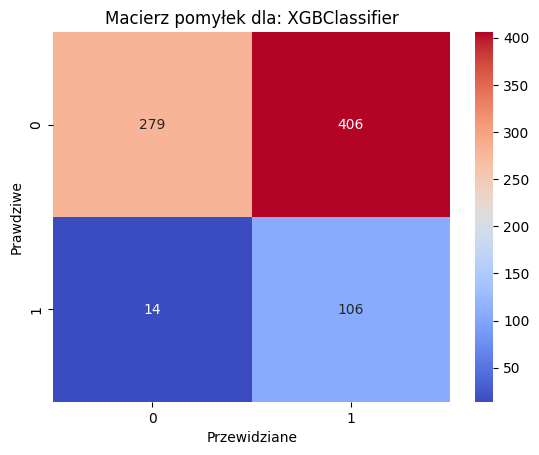

In [274]:
new_treshold = 0.45

death_prob = xgb_grid.predict_proba(X_test_scaled)[:, 1]

y_pred_custom = (death_prob >= new_treshold).astype(int)

recall = recall_score(y_pred=y_pred_custom, y_true=y_test)
precision = precision_score(y_pred=y_pred_custom, y_true=y_test)
conf_mat = confusion_matrix(y_pred=y_pred_custom, y_true=y_test)


print(f"Nowa wartosc metryki recall dla progu {new_treshold}: {recall}")
print(f"Nowa wartosc metryki precision dla progu {new_treshold}: {precision}")
plt.title(f"Macierz pomyłek dla: {name}")
sns.heatmap(conf_mat, annot=True, fmt="d", cmap='coolwarm')
plt.ylabel("Prawdziwe")
plt.xlabel("Przewidziane")
plt.show()

To jest ostateczny najlepszy wynik jaki mozna przyjac tworzac model predykcyjny rozwiazujacy problemy onkologiczne. Z perspektywy biznesowej bylby on zupelnie nieprzydatny ze wzgledu na precyzje wynoszaca zaledwie 20%. W medycynie jednak podejscie zycia ponad pieniadze jest jak najbardziej wlasciwe, stad tez ostateczny wybor modelu XGBClassifier dla ktorego recall wyniosl blisko 90%. Lepiej jest wyslac kilkudziesieciu pacjentow na dodatkowe badania niz przeoczyc dziesiatki chorych, ktorzy tych badan i tego leczenia potrzebuja.